In [182]:
import networkx as nx
from spidercat.draw import draw_spanning_forest_solution
from spidercat.spanning_tree import find_min_height_roots, match_forest_leaves_to_marked_edges
from spidercat.utils import load_solution_triplet

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [183]:


def find_mdst(G):
    """
    Finds the Absolute Center and Minimum Diameter Spanning Tree of an unweighted graph.
    """
    # 1. Compute All-Pairs Shortest Paths (APSP)/
    # Using dictionary comprehension for $O(n^2)$ lookup efficiency
    apsp = dict(nx.all_pairs_shortest_path_length(G))

    min_radius = float('inf')
    absolute_center = None
    is_edge_center = False

    # 2. Check all vertices for their eccentricity
    for v in G.nodes():
        eccentricity = max(apsp[v].values())
        if eccentricity < min_radius:
            min_radius = eccentricity
            absolute_center = v
            is_edge_center = False

    # 3. Check all edge midpoints for their eccentricity
    for u, v in G.edges():
        # Distance from an edge midpoint to any node w is min(d(u,w), d(v,w)) + 0.5
        edge_eccentricity = max(min(apsp[u][w], apsp[v][w]) + 0.5 for w in G.nodes())
        if edge_eccentricity < min_radius:
            min_radius = edge_eccentricity
            absolute_center = (u, v)
            is_edge_center = True

    # 4. Construct the Spanning Tree
    if not is_edge_center:
        # If the center is a vertex, a simple BFS tree suffices
        mdst = nx.bfs_tree(G, absolute_center).to_undirected()
    else:
        # If the center is on an edge, we subdivide the edge with a dummy node,
        # run BFS from the dummy node, and then replace the dummy with the original edge.
        u, v = absolute_center
        G_temp = G.copy()
        G_temp.remove_edge(u, v)
        dummy_node = 'TEMP_CENTER'
        G_temp.add_edge(u, dummy_node)
        G_temp.add_edge(v, dummy_node)

        mdst_temp = nx.bfs_tree(G_temp, dummy_node).to_undirected()

        # Clean up the dummy node to restore the original graph structure in the tree
        mdst_temp.remove_node(dummy_node)
        mdst_temp.add_edge(u, v)
        mdst = mdst_temp

    return mdst, absolute_center, min_radius

# --- Example Usage ---
# Generate a random 3-regular graph (which is likely an expander)
n_nodes = 100
G = nx.random_regular_graph(3, n_nodes)

# Ensure it is connected
if nx.is_connected(G):
    tree, center, radius = find_mdst(G)
    print(f"Absolute Center: {center}")
    print(f"Tree Radius from Center: {radius}")

    # The diameter of the resulting tree will be roughly 2 * radius
    tree_diameter = nx.diameter(tree)
    print(f"Resulting MDST Diameter: {tree_diameter}")
else:
    print("Graph is not connected. MDST cannot be formed.")

Absolute Center: (18, 75)
Tree Radius from Center: 6.5
Resulting MDST Diameter: 13


Absolute Center: 0
M: {(0, 7): 1, (0, 1): 1, (0, 2): 1, (1, 2): 1, (1, 4): 2, (2, 3): 2, (3, 4): 2, (3, 6): 2, (4, 5): 2, (5, 6): 2, (5, 7): 2, (6, 7): 2}
Matchings: {3: [(3, 4), (3, 6), (3, 6)], 4: [(3, 4), (4, 5)], 5: [(4, 5), (5, 6)], 6: [(5, 6)], 1: [(1, 2), (1, 4), (1, 4)], 2: [(2, 3), (2, 3)], 7: [(5, 7), (5, 7), (6, 7), (6, 7)]}


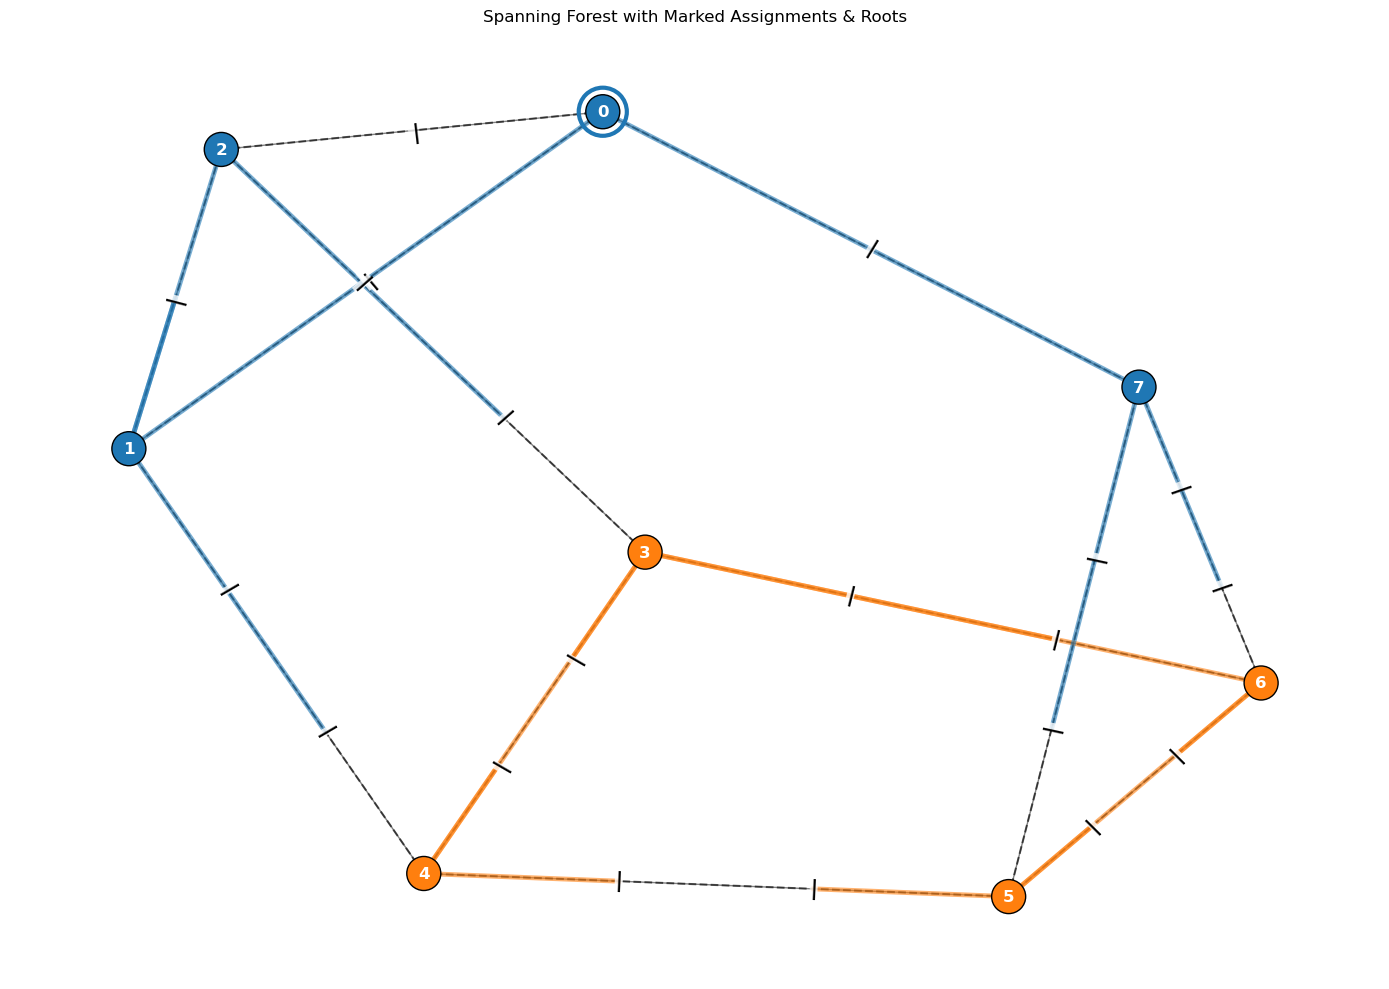

In [192]:


grf, forest, M, matchings = load_solution_triplet(20, 2, 2)
tree, center, radius = find_mdst(grf)
print(f"Absolute Center: {center}")

matchings = match_forest_leaves_to_marked_edges(grf, tree, M)
print(f"M: {M}")
print(f"Matchings: {matchings}")
draw_spanning_forest_solution(grf, forest, M, matchings, {0: center[0] if isinstance(center, tuple) else center})


=== Starting Elegant Extraction (BFS) ===
Init Root 0 (Tree 0) -> Q0
  New flag initialised (0, 10): CNOT Q0 -> Q20
  Node 0 -> Branch 8: Spawned CNOT Q0 -> Q1
  Node 0 -> Primary 9 (Inherits Q0)
  Mark on 8: Spawned CNOT Q1 -> Q2
  Node 8 -> Primary 7 (Inherits Q1)
  Mark on 9: Spawned CNOT Q0 -> Q3
  Node 9 -> Primary 1 (Inherits Q0)
  Node 7 -> Branch 25: Spawned CNOT Q1 -> Q4
  Node 7 -> Primary 27 (Inherits Q1)
  Node 1 -> Branch 11: Spawned CNOT Q0 -> Q5
  Node 1 -> Primary 12 (Inherits Q0)
  Mark on 25: Spawned CNOT Q4 -> Q6
  Node 25 -> Primary 24 (Inherits Q4)
  Mark on 27: Spawned CNOT Q1 -> Q7
  Node 27 -> Primary 26 (Inherits Q1)
  Mark on 11: Spawned CNOT Q5 -> Q8
  Node 11 -> Primary 2 (Inherits Q5)
  Mark on 12: Spawned CNOT Q0 -> Q9
  Node 12 -> Primary 13 (Inherits Q0)
  New flag initialised (24, 5): CNOT Q4 -> Q21
  Node 24 serves as a sink point for Q4
  New flag initialised (26, 6): CNOT Q1 -> Q22
  Node 26 serves as a sink point for Q1
  Node 2 -> Branch 14: Spawne

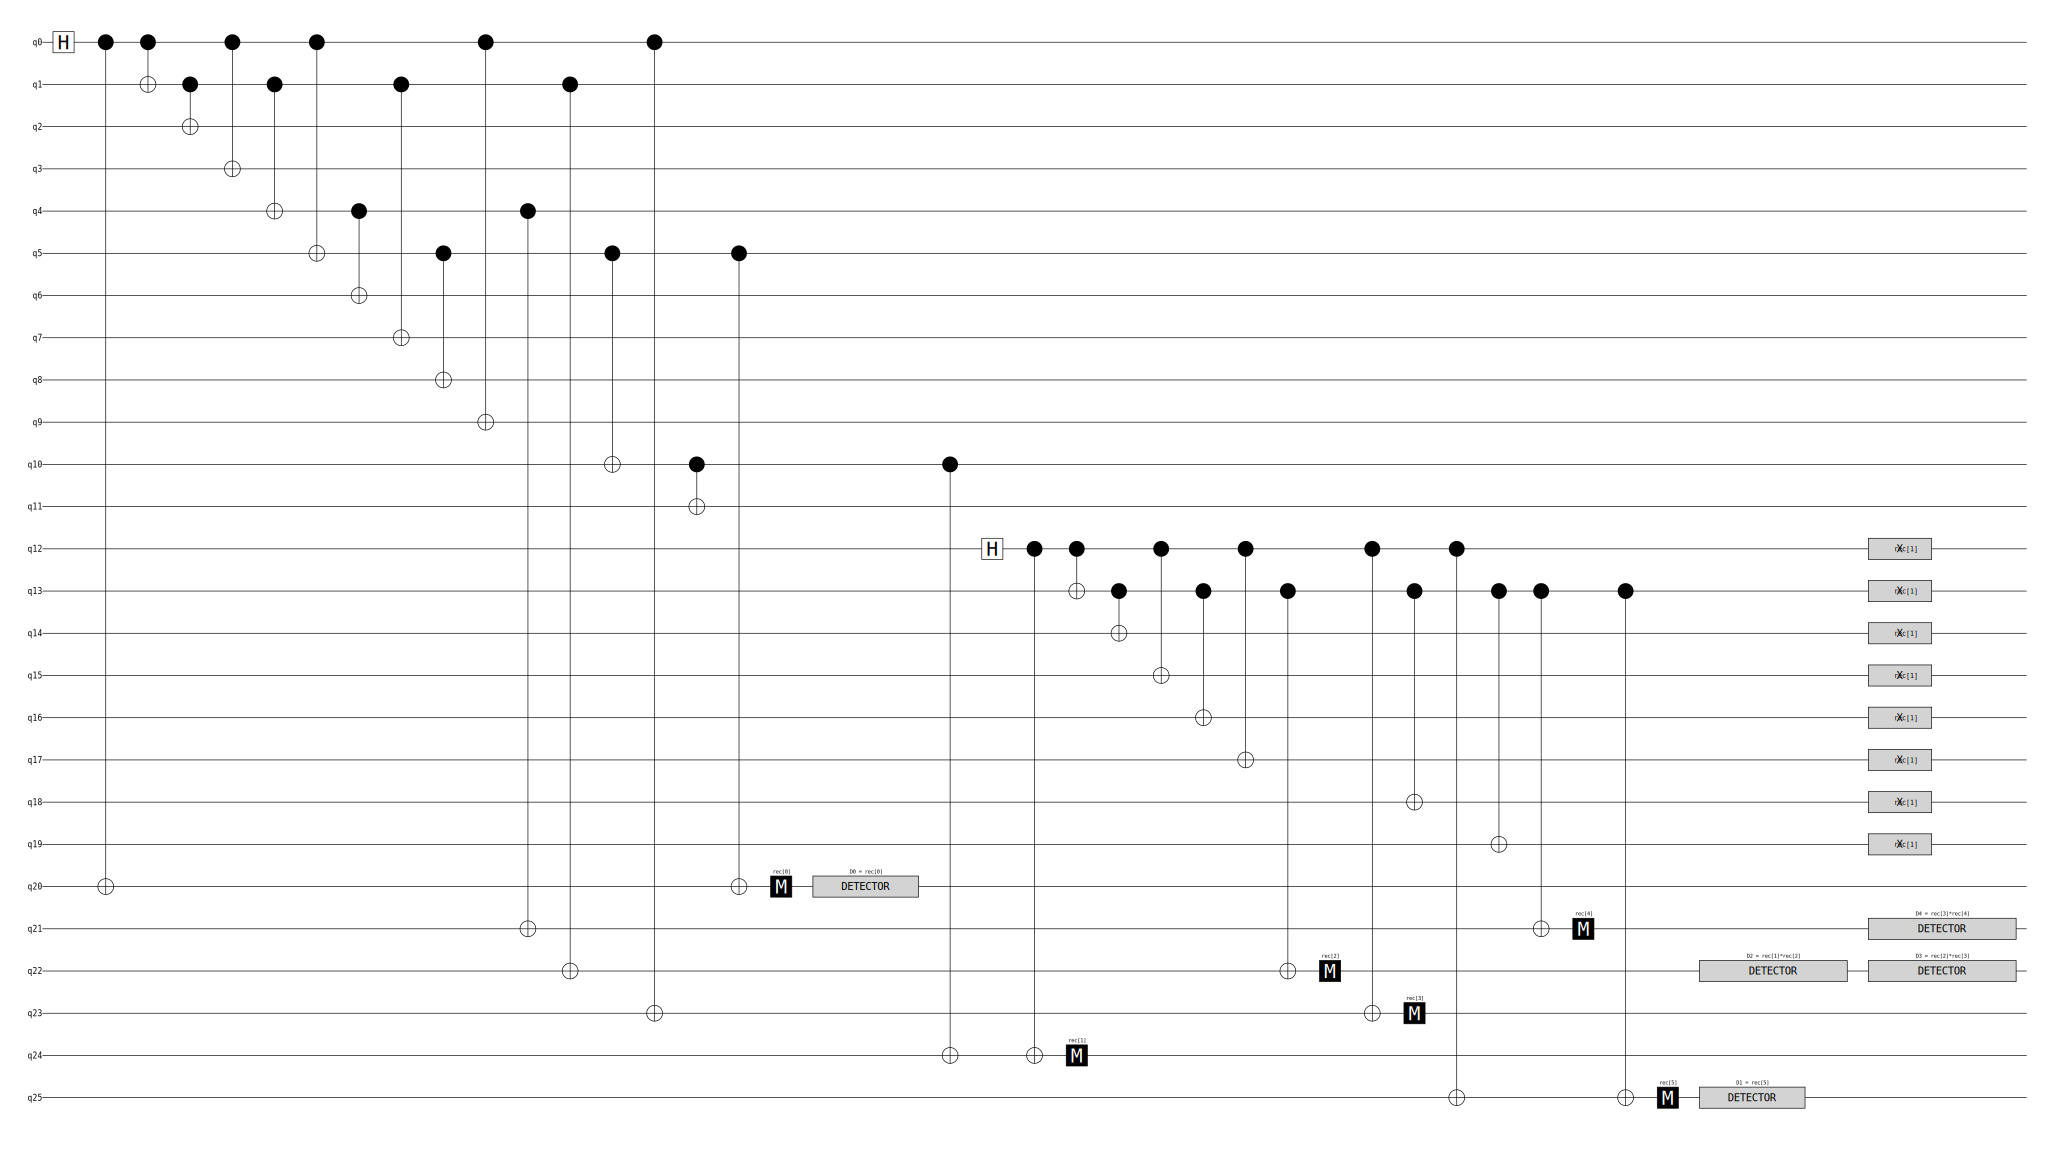

In [193]:
from spidercat.circuit_extraction import extract_circuit_rooted
roots = find_min_height_roots(forest)
grf, forest, M, matchings
circ = extract_circuit_rooted(grf, forest, roots, M, matchings, verbose=True)
circ.diagram('timeline-svg')

In [194]:
circ.append("M", range(12))
circ.compile_detector_sampler().sample(10)

array([[False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False]])

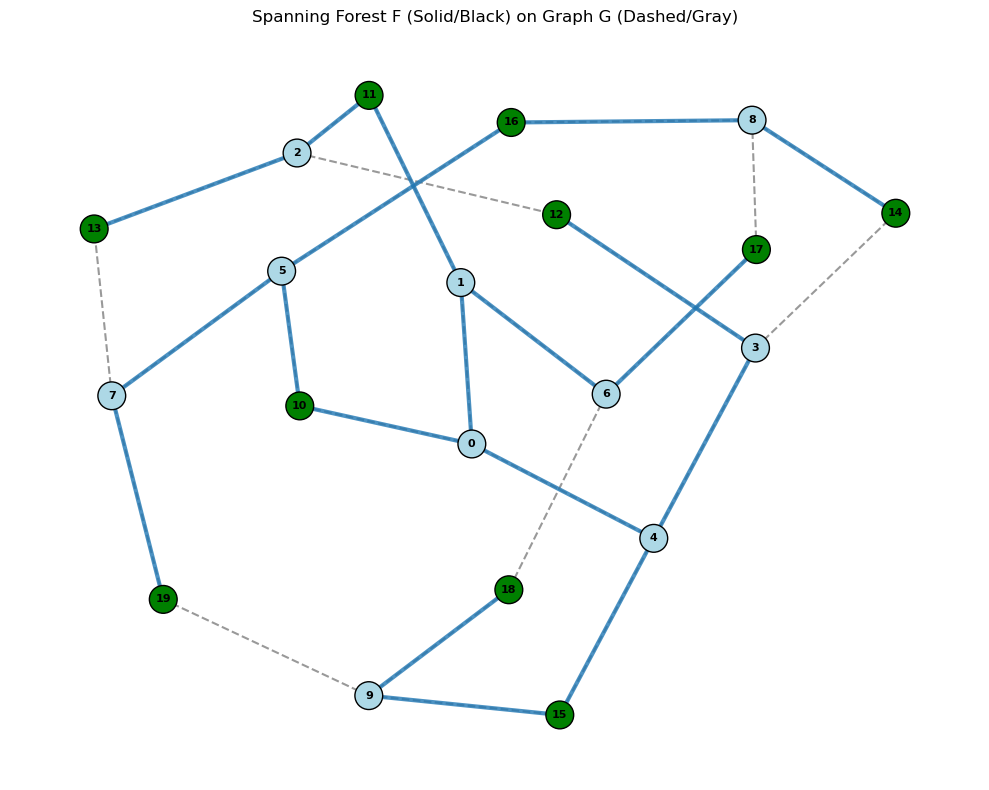

In [152]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_forest_on_graph(
        G: nx.Graph,
        F: nx.Graph,
        seed: int = 42,
        figsize: tuple[int, int] = (10, 8)
) -> None:
    """
    Draws the spanning forest F over the graph G.
    Differentiates original nodes, marked nodes, and flagged nodes by color.
    """
    plt.figure(figsize=figsize)

    # 1. Compute a single, locked layout based on G
    # A fixed seed ensures the graph looks the same every time you run it
    pos = nx.spring_layout(G, seed=seed)

    # 2. Map node colors based on the metadata we injected earlier
    node_colors = []
    for node, data in G.nodes(data=True):
        if data.get("is_flag"):
            node_colors.append("orange")    # Implicit Flags (edge_diff)
        elif data.get("is_mark"):
            node_colors.append("green")       # Explicit Marks
        else:
            node_colors.append("lightblue") # Original Forest/Graph Nodes

    # 3. Draw the Background: Graph G
    # Draw the nodes first with our computed colors
    cmap = plt.cm.tab10
    colors = cmap.colors
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=400,
        edgecolors="black" # Gives nodes a clean border
    )

    # Draw G's edges faintly in the background
    nx.draw_networkx_edges(
        G, pos,
        edge_color="gray",
        width=1.5,
        alpha=0.8,
        style="dashed" # Helps distinguish from F
    )

    # 4. Draw the Foreground: Forest F
    # Draw F's edges thickly and prominently
    nx.draw_networkx_edges(
        F, pos,
        edge_color=colors[0],
        width=3.0,
        alpha=0.8
    )

    # 5. Add Labels
    # For a cleaner look, you might only want to label original nodes,
    # but here we label everything to help you debug.
    nx.draw_networkx_labels(
        G, pos,
        font_size=8,
        font_weight="bold"
    )

    plt.title("Spanning Forest F (Solid/Black) on Graph G (Dashed/Gray)")
    plt.axis("off") # Hide the bounding box
    plt.tight_layout()
    plt.show()

visualize_forest_on_graph(G, F)